In [14]:
import sqlite3
import pandas as pd
import numpy as np
import mne
from mne.preprocessing import ICA
from io import BytesIO
from scipy.signal import welch

In [43]:
db_path = "/Users/sarah-rosemay/Downloads/subj-1_ses-S001_task-sarah breathong test_run-001_20010118_223429_eeg.db"
data_raw = pd.read_sql_query('SELECT * FROM "data_db818d76-d9a5-4dce-aad7-ab995e387ef6"', conn)
fp1_list = []
fp2_list = []

for b in data_raw["data"]:
    chunk = np.load(BytesIO(b), allow_pickle=True)
    fp2_list.append(chunk[2])
    fp1_list.append(chunk[3])

fp1 = np.concatenate(fp1_list)
fp2 = np.concatenate(fp2_list)

eeg_data = np.vstack([fp1, fp2]) / 1e6

In [34]:
info = mne.create_info(
    ch_names=["Fp1", "Fp2"],
    sfreq=250,
    ch_types=["eeg", "eeg"]
)

raw = mne.io.RawArray(eeg_data, info)

raw.filter(0.1, 40)

Creating RawArray with float64 data, n_channels=2, n_times=45925
    Range : 0 ... 45924 =      0.000 ...   183.696 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 8251 samples (33.004 s)



[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,Not available
Good channels,2 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.10 Hz
Lowpass,40.00 Hz


In [35]:
ica = ICA(n_components=2, random_state=97, max_iter="auto")
ica.fit(raw)

Fitting ICA to data using 2 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 0.0s.


/var/folders/33/qg_ry0_n2kb_gsw589xg9z_w0000gn/T/ipykernel_74826/3214842021.py:2: RuntimeWarning: Using n_components=2 (resulting in n_components_=2) may lead to an unstable mixing matrix estimation because the ratio between the largest (2) and smallest (4e-31) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 1
  ica.fit(raw)


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,9 iterations on raw data (45925 samples)
ICA components,2
Available PCA components,2
Channel types,eeg
ICA components marked for exclusion,—


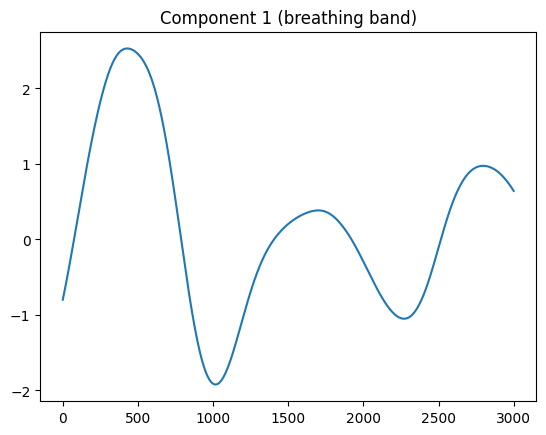

In [41]:
def bandpass(data, low=0.1, high=0.4, fs=250):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, data)

breath_signal = bandpass(sources[best_comp])

plt.plot(breath_signal[:3000])
plt.title(f"Component {best_comp} (breathing band)")
plt.show()